### Logistic Regression on the Framingham Heart Study Dataset

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

**Obejctive**
- The objective of this assignment is to apply logistic regression techniques to predict the likelihood of developing coronary heart disease (CHD) based on various risk factors in the dataset.

In [2]:
df = pd.read_csv("D:\\Internship\\ds-aiml-genai-internship\\Data\\Framingham.csv")

**1. Understand the Dataset**
- Use the framingham.csv file provided
- Load the dataset into a Pandas DataFrame.
- Identify the target variable.
- Display descriptive statistics of the dataset

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
df.shape

(4238, 16)

In [6]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [8]:
# Target variable
df["TenYearCHD"].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

#### Check Missing Values

In [9]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [ ]:
# Fill missing numerical values using mean.
imputer = SimpleImputer(strategy="mean")

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

**2. Exploratory Data Analysis (EDA)**
- *Data Visualization*:
  - Plot histograms of numerical variables to check distributions.
  - Use bar plots and count plots for categorical variables.
  - Check relationships between variables using scatter plots and boxplots.
- *Correlation Analysis*:
  - Generate a heatmap using seaborn to show correlations between variables.
  - Highlight features highly correlated with the target variable.

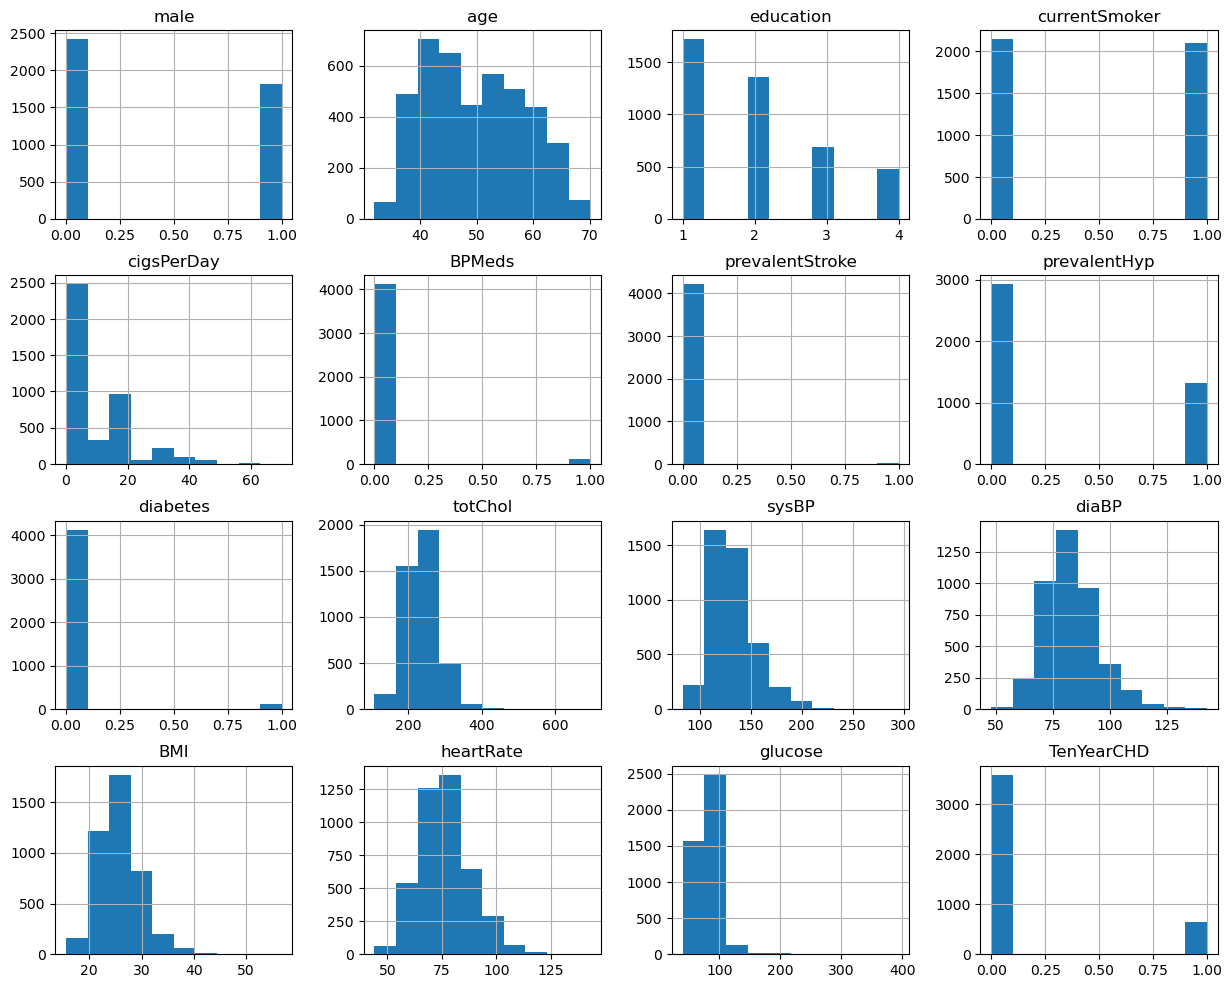

In [12]:
# Histogram
df.hist(figsize=(15,12))
plt.show()

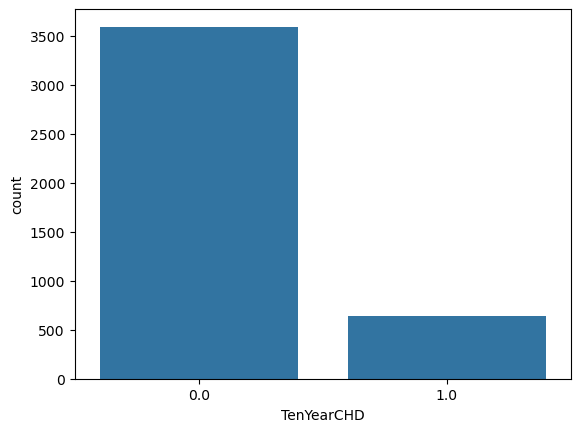

In [13]:
# Countplot
sns.countplot(x="TenYearCHD", data=df)
plt.show()

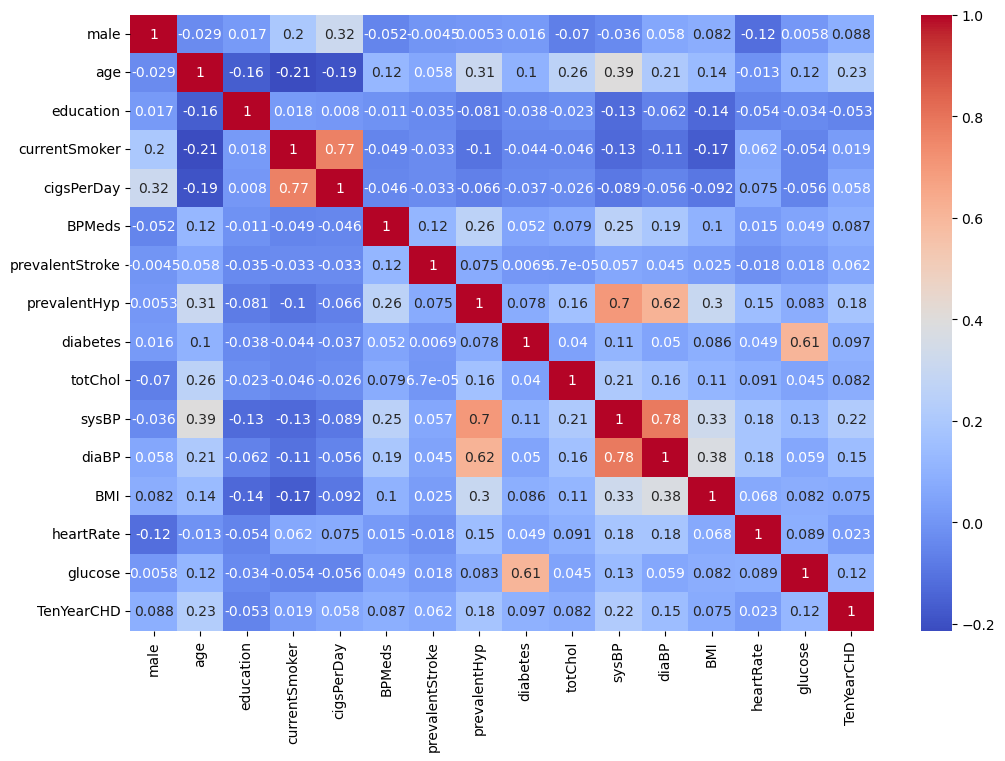

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

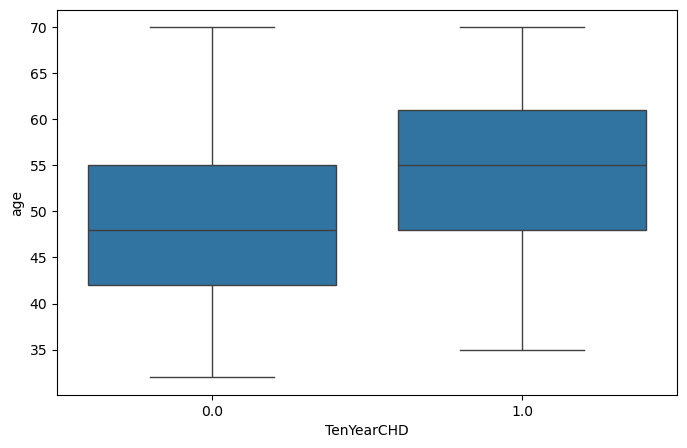

In [15]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="TenYearCHD", y="age", data=df)
plt.show()

**3. Data Preprocessing**
- Identify missing values.
- Impute missing values for numerical columns using the mean, median, or other suitable methods.
- Drop rows/columns if necessary.
- Normalize or standardize numerical variables.
- Convert categorical variables into numerical variables.
- Split the data into training (70%) and testing (30%) sets using train_test_split() from sklearn.

In [16]:
# Split Features and Target
X = df.drop("TenYearCHD", axis=1)

y = df["TenYearCHD"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**4. Build a Logistic Regression Model**
- *Model Training:*
  - Import LogisticRegression
  - Fit the logistic regression model to the training data.
  - Print the model coefficients and intercept to understand the influence of each variable.
- *Probability Predictions:*
  - Use .predict_proba() to predict the probability of CHD.
- *Binary Predictions:*
  - Use .predict() to predict the binary outcome (0 or 1).

In [21]:
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
# Model Coefficients
print(model.coef_)

[[ 0.20607288  0.56401637  0.0200954  -0.01128004  0.27268042  0.04812394
   0.06851345  0.09414298 -0.02257498  0.02453243  0.2660493   0.03776251
  -0.02323828 -0.04764772  0.23638328]]


In [23]:
# Intercept
print(model.intercept_)

[-1.95298862]


In [24]:
# Prediction
y_pred = model.predict(X_test)

In [25]:
y_prob = model.predict_proba(X_test)

**5. Model Evaluation**
- *Performance Metrics:*
  - Evaluate the model using metrics like:
    - Accuracy Score
    - Precision
    - Recall
    - F1 Score
    - ROC-AUC Score
- *Confusion Matrix:*
  - Plot the confusion matrix.
- *ROC Curve:*
  - Plot the ROC curve to evaluate the trade-off between sensitivity and specificity.

In [26]:
# Accuracy
accuracy_score(y_test, y_pred)

0.8608490566037735

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92      1084
         1.0       0.69      0.11      0.18       188

    accuracy                           0.86      1272
   macro avg       0.78      0.55      0.55      1272
weighted avg       0.84      0.86      0.81      1272



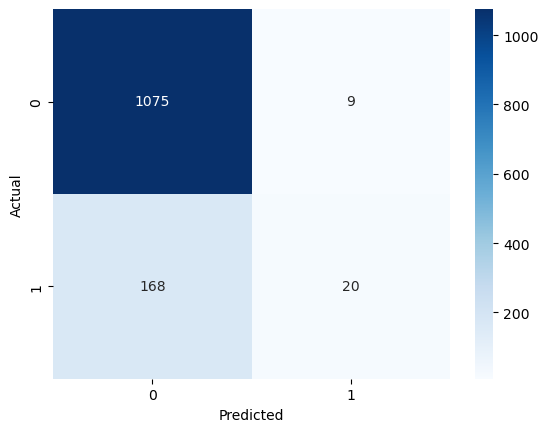

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

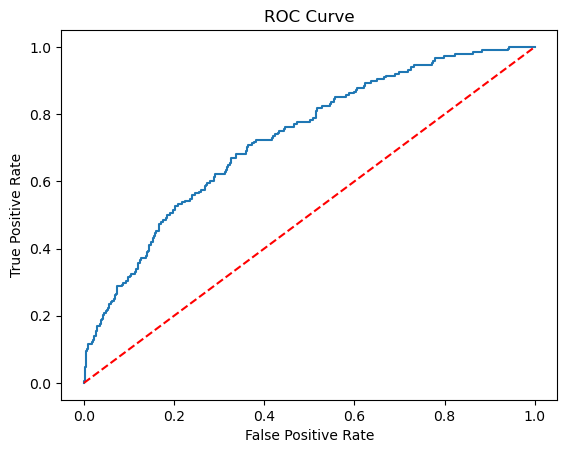

In [29]:
# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [30]:
# ROC-AUC Score
roc_auc_score(y_test, y_prob)

0.7279333830572347

**6. Hyperparameter Tuning**
- Use grid search (GridSearchCV) to tune the regularization parameter (C) and penalty type (l1, l2).
- Compare the performance of the optimized model with the baseline model.

In [31]:
param_grid = {
    "C":[0.01,0.1,1,10],
    "penalty":["l1","l2"],
    "solver":["liblinear"]
}

In [32]:
# Create Grid Search
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [33]:
# Train
grid.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


**7. Interpret the Results**
- *Coefficient Analysis:*
  - Interpret the model coefficients to understand the impact of each feature on CHD.
- *Insights:*
  - Which factors increase the likelihood of CHD?

In [34]:
# Best Parameters
print(grid.best_params_)

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [36]:
# Best Score
print(grid.best_score_)

0.850302916744738


In [37]:
# Best Model
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

accuracy_score(y_test, pred)

0.8577044025157232

In [38]:
# Interpretation
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_model.coef_[0]
})

coef.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,age,0.521105
10,sysBP,0.263544
4,cigsPerDay,0.227743
14,glucose,0.192052
0,male,0.180482
7,prevalentHyp,0.080182
6,prevalentStroke,0.053797
5,BPMeds,0.036003
11,diaBP,0.009570
2,education,0.000000
